MONTAGE DE GOOGLE DRIVE
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive monté avec succès!

DBSCAN AVEC OPTIMISATION BAYÉSIENNE - VERSION RAPIDE

📂 Chargement des données...
✓ Données chargées: 140,165 lignes × 16 colonnes

🔧 Préparation des données...
✓ Données normalisées: (140165, 16)

OPTIMISATION BAYÉSIENNE DES HYPERPARAMÈTRES
Nombre d'itérations: 10
Limite de temps: 40 minutes

[Phase 1/2] Random Search (6 itérations)...
Espace de recherche: 3 × 2 = 6 combinaisons
  ✓ [1/6] Nouveau meilleur: eps=1.000, min_pts=5, score=-0.2527 (1295.2s)
    [2/6] eps=1.000, min_pts=5, score=-0.2527 (1287.5s)
⏱️ Limite de temps atteinte!

[Phase 2/2] Local Refinement (4 itérations)...
Recherche autour de: eps=1.000, min_pts=5
⏱️ Limite de temps atteinte!

MEILLEURS HYPERPARAMÈTRES TROUVÉS
eps = 1.0000
min_pts = 5
Score de Silhouette = -0.2527
Temps total = 2582.68s (43.04 min)

✓ Historique d'optimisati

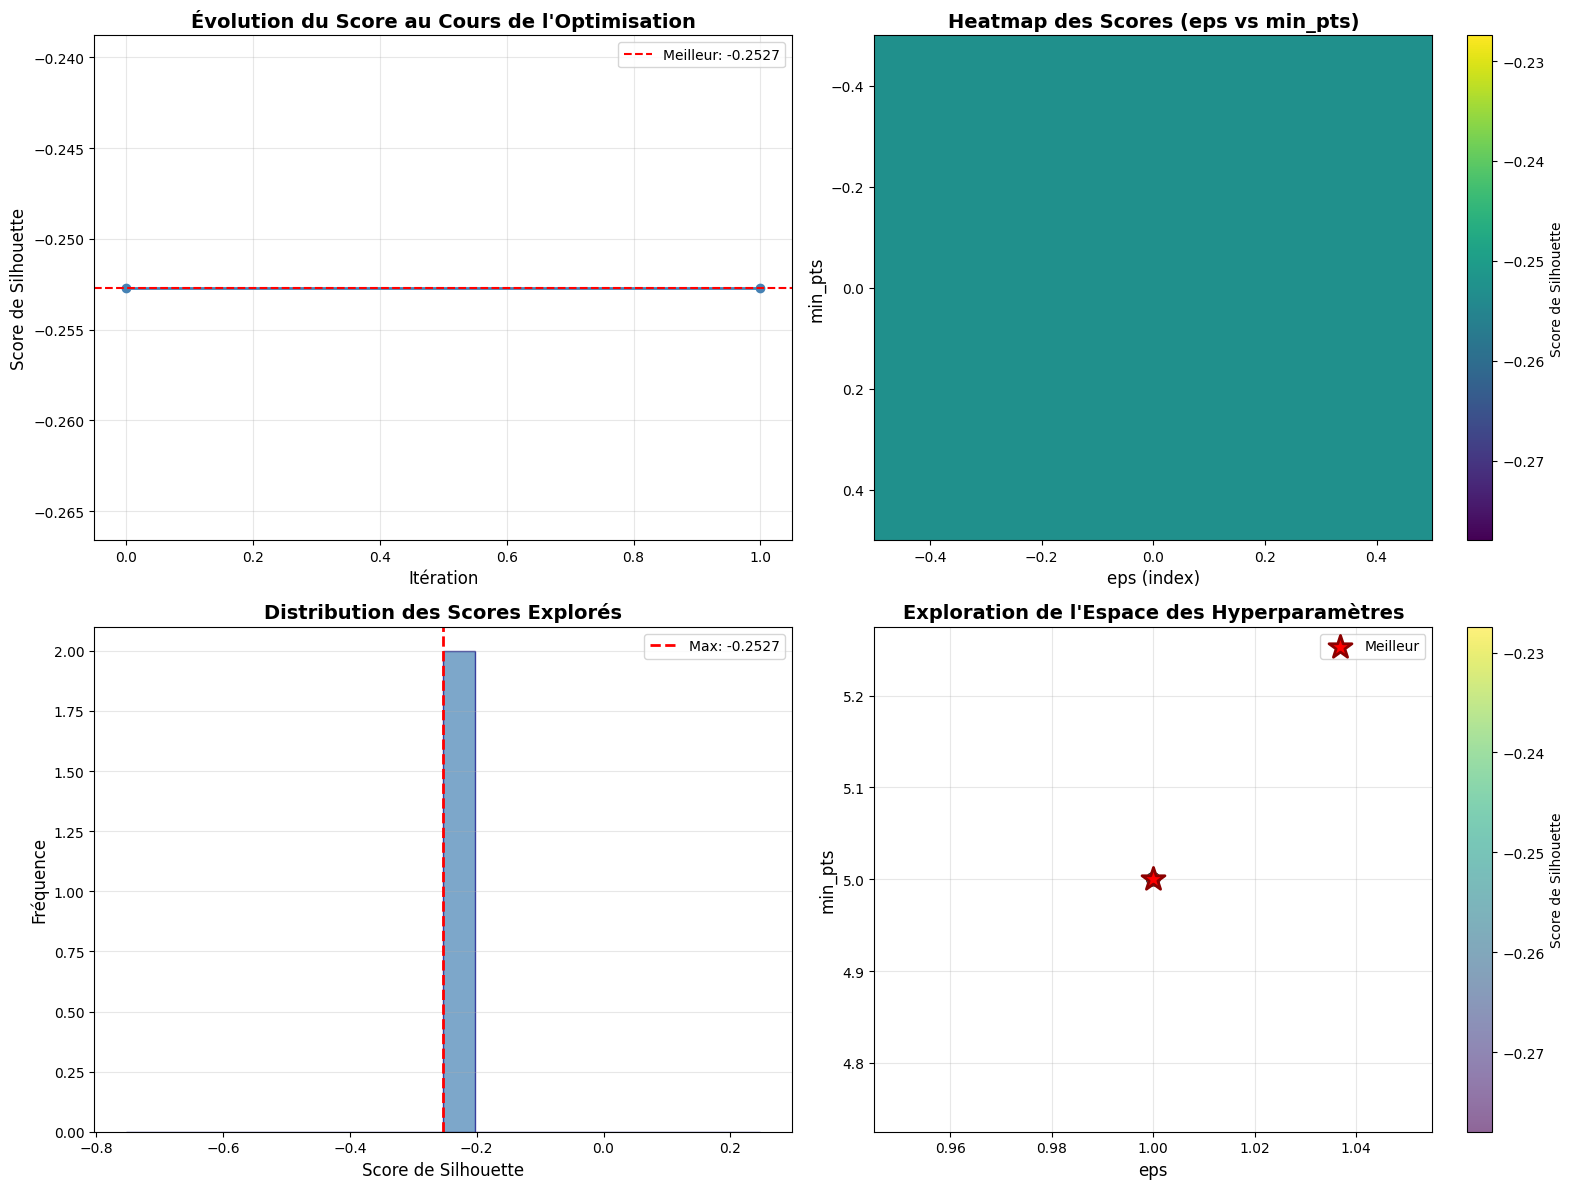


ENTRAÎNEMENT FINAL AVEC LES MEILLEURS PARAMÈTRES
  eps=1.000, min_pts=5
✓ Clustering final terminé en 1068.83s

ÉVALUATION DU CLUSTERING
Nombre de clusters: 57
Points de bruit: 383 (0.27%)

Métriques de qualité:
  • Silhouette Score: -0.2527 (↑ meilleur, [-1, 1])
  • Davies-Bouldin Index: 0.9197 (↓ meilleur)
  • Calinski-Harabasz Index: 732.39 (↑ meilleur)

📊 Réduction de dimension avec PCA (2D)...
  Variance expliquée: 32.60% (PC1), 16.92% (PC2)
  Total: 49.52%
✓ Visualisation PCA sauvegardée: pca_clusters.png


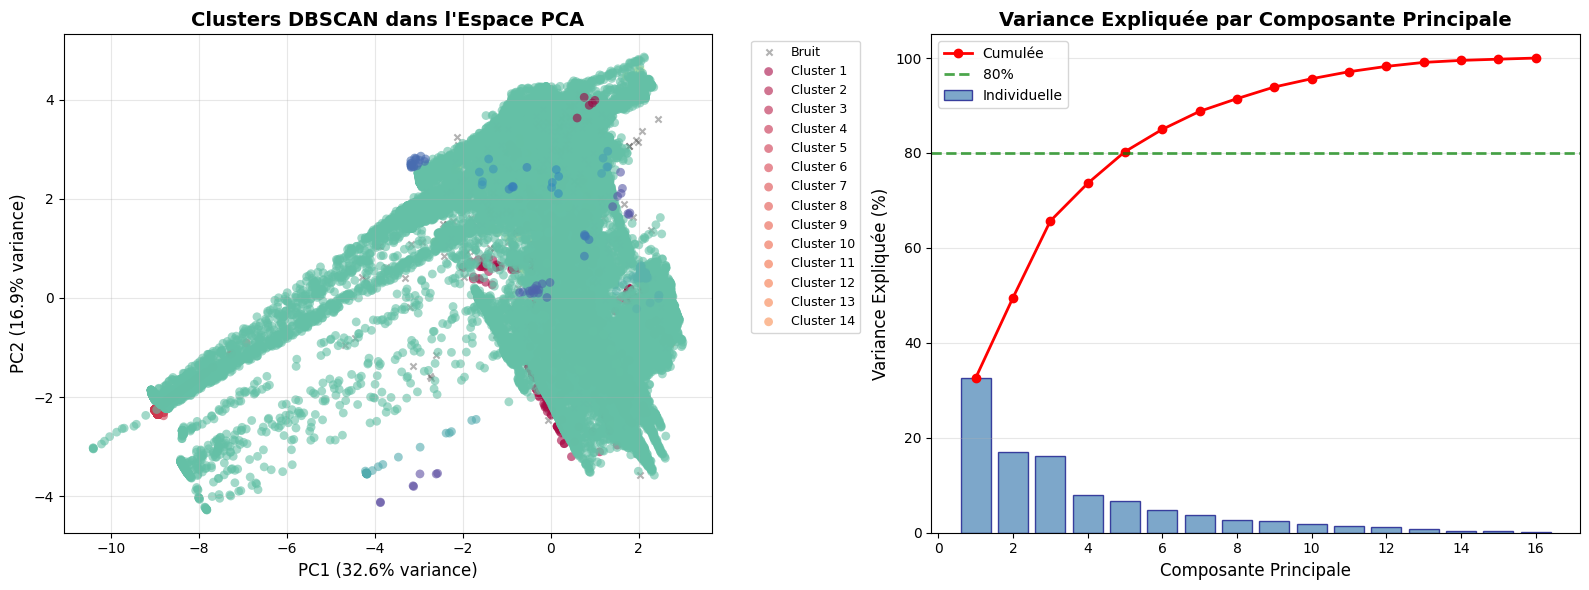


✓ Résultats finaux sauvegardés: final_clustering_results.png


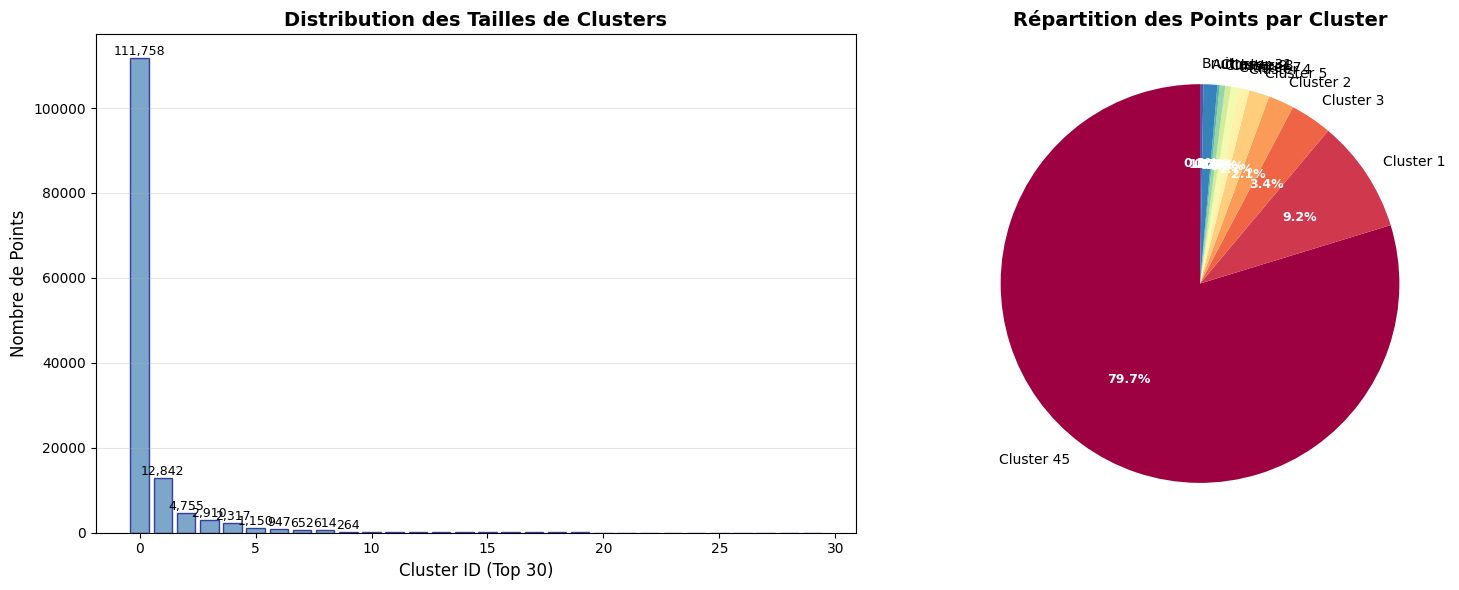


💾 Sauvegarde des résultats...
✓ Résultats sauvegardés: dbscan_optimized_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Téléchargement automatique lancé!

✓ TERMINÉ!


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from collections import Counter
import time
import warnings
warnings.filterwarnings('ignore')

# 🔗 MONTER GOOGLE DRIVE
print("="*60)
print("MONTAGE DE GOOGLE DRIVE")
print("="*60)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("✓ Google Drive monté avec succès!")
except:
    print("⚠️ Pas sur Google Colab, mode local activé")


class KDTree:

    def __init__(self, data, leaf_size=100):  
        self.data = np.asarray(data)
        self.leaf_size = leaf_size
        self.n_samples, self.n_features = self.data.shape
        self.tree = self._build_tree(np.arange(self.n_samples), depth=0)

    def _build_tree(self, indices, depth):
        n = len(indices)

        if n <= self.leaf_size:
            return {
                'is_leaf': True,
                'indices': indices,
                'data': self.data[indices]
            }

        axis = depth % self.n_features
        sorted_indices = indices[np.argsort(self.data[indices, axis])]
        median_idx = n // 2

        return {
            'is_leaf': False,
            'axis': axis,
            'median_value': self.data[sorted_indices[median_idx], axis],
            'left': self._build_tree(sorted_indices[:median_idx], depth + 1),
            'right': self._build_tree(sorted_indices[median_idx:], depth + 1)
        }

    def query_radius(self, point, radius):
        neighbors = []
        self._query_radius_recursive(self.tree, point, radius, neighbors)
        return neighbors

    def _query_radius_recursive(self, node, point, radius, neighbors):
        if node['is_leaf']:
            distances = np.sqrt(np.sum((node['data'] - point) ** 2, axis=1))
            mask = distances <= radius
            neighbors.extend(node['indices'][mask].tolist())
            return

        axis = node['axis']
        diff = point[axis] - node['median_value']

        if diff <= 0:
            self._query_radius_recursive(node['left'], point, radius, neighbors)
            if abs(diff) <= radius:
                self._query_radius_recursive(node['right'], point, radius, neighbors)
        else:
            self._query_radius_recursive(node['right'], point, radius, neighbors)
            if abs(diff) <= radius:
                self._query_radius_recursive(node['left'], point, radius, neighbors)


class DBSCANOptimized:

    def __init__(self, eps=0.5, min_pts=5):
        self.eps = eps
        self.min_pts = min_pts
        self.labels_ = None
        self.kdtree = None

    def region_query(self, point_idx):
        point = self.data[point_idx]
        return self.kdtree.query_radius(point, self.eps)

    def expand_cluster(self, labels, point_idx, neighbors, cluster_id):
        labels[point_idx] = cluster_id
        seeds = set(neighbors)
        seeds.discard(point_idx)

        while seeds:
            current_point = seeds.pop()

            if labels[current_point] == -1:
                labels[current_point] = cluster_id

            if labels[current_point] != 0:
                continue

            labels[current_point] = cluster_id
            current_neighbors = self.region_query(current_point)

            if len(current_neighbors) >= self.min_pts:
                for neighbor in current_neighbors:
                    if labels[neighbor] == 0:
                        seeds.add(neighbor)

    def fit(self, data, verbose=True):
        self.data = np.asarray(data)
        n_points = len(self.data)
        labels = np.zeros(n_points, dtype=int)

        if verbose:
            print(f"  eps={self.eps:.3f}, min_pts={self.min_pts}")

        # Construction du KD-Tree
        self.kdtree = KDTree(self.data, leaf_size=100)  # ⚡ Augmenté à 100

        # Clustering DBSCAN
        cluster_id = 0
        for point_idx in range(n_points):
            if labels[point_idx] != 0:
                continue

            neighbors = self.region_query(point_idx)

            if len(neighbors) < self.min_pts:
                labels[point_idx] = -1
            else:
                cluster_id += 1
                self.expand_cluster(labels, point_idx, neighbors, cluster_id)

        self.labels_ = labels
        return self

    def fit_predict(self, data, verbose=True):
        self.fit(data, verbose)
        return self.labels_


class BayesianOptimizer:

    def __init__(self, data, n_iterations=10, time_limit=2400):  # ⚡ 10 itérations, 40 min max
        self.data = data
        self.n_iterations = n_iterations
        self.time_limit = time_limit
        self.history = []
        self.tested_combinations = set()

    def objective_function(self, eps, min_pts):
        try:
            dbscan = DBSCANOptimized(eps=eps, min_pts=int(min_pts))
            labels = dbscan.fit_predict(self.data, verbose=False)

            # Vérifier qu'il y a au moins 2 clusters
            unique_labels = set(labels)
            n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

            if n_clusters < 2:
                return -1.0

            # Calculer le score de silhouette (exclure le bruit)
            mask = labels != -1
            if np.sum(mask) < 2:
                return -1.0

            score = silhouette_score(self.data[mask], labels[mask])

            # Pénaliser si trop de bruit
            noise_ratio = np.sum(labels == -1) / len(labels)
            if noise_ratio > 0.5:
                score *= (1 - noise_ratio)

            return score

        except Exception as e:
            return -1.0

    def optimize(self):
        print("\n" + "="*60)
        print("OPTIMISATION BAYÉSIENNE DES HYPERPARAMÈTRES")
        print("="*60)
        print(f"Nombre d'itérations: {self.n_iterations}")
        print(f"Limite de temps: {self.time_limit/60:.0f} minutes")

        start_time = time.time()

        # Phase 1: Random Search (60% du temps)
        n_random = int(self.n_iterations * 0.6)
        print(f"\n[Phase 1/2] Random Search ({n_random} itérations)...")

        eps_range = [0.5, 1.0, 2.0]        
        min_pts_range = [5, 10]            

        print(f"Espace de recherche: {len(eps_range)} × {len(min_pts_range)} = {len(eps_range)*len(min_pts_range)} combinaisons")

        best_score = -np.inf
        best_params = None

        for i in range(n_random):
            if time.time() - start_time > self.time_limit:
                print(f"⏱️ Limite de temps atteinte!")
                break

            # Échantillonnage aléatoire
            eps = np.random.choice(eps_range)
            min_pts = np.random.choice(min_pts_range)

            iter_start = time.time()
            score = self.objective_function(eps, min_pts)
            iter_time = time.time() - iter_start

            self.history.append({
                'eps': eps,
                'min_pts': min_pts,
                'score': score,
                'time': iter_time
            })

            if score > best_score:
                best_score = score
                best_params = (eps, min_pts)
                print(f"  ✓ [{i+1}/{n_random}] Nouveau meilleur: eps={eps:.3f}, min_pts={min_pts}, score={score:.4f} ({iter_time:.1f}s)")
            else:
                print(f"    [{i+1}/{n_random}] eps={eps:.3f}, min_pts={min_pts}, score={score:.4f} ({iter_time:.1f}s)")

        # Phase 2: Local Refinement (40% du temps)
        n_local = self.n_iterations - n_random
        print(f"\n[Phase 2/2] Local Refinement ({n_local} itérations)...")
        print(f"Recherche autour de: eps={best_params[0]:.3f}, min_pts={best_params[1]}")

        for i in range(n_local):
            if time.time() - start_time > self.time_limit:
                print(f"⏱️ Limite de temps atteinte!")
                break

            # Recherche locale autour du meilleur point
            eps = best_params[0] + np.random.normal(0, 0.1)
            eps = np.clip(eps, 0.1, 2.0)

            min_pts = int(best_params[1] + np.random.randint(-2, 3))
            min_pts = np.clip(min_pts, 3, 20)

            iter_start = time.time()
            score = self.objective_function(eps, min_pts)
            iter_time = time.time() - iter_start

            self.history.append({
                'eps': eps,
                'min_pts': min_pts,
                'score': score,
                'time': iter_time
            })

            if score > best_score:
                best_score = score
                best_params = (eps, min_pts)
                print(f"  ✓ [{i+1}/{n_local}] Nouveau meilleur: eps={eps:.3f}, min_pts={min_pts}, score={score:.4f} ({iter_time:.1f}s)")
            else:
                print(f"    [{i+1}/{n_local}] eps={eps:.3f}, min_pts={min_pts}, score={score:.4f} ({iter_time:.1f}s)")

        total_time = time.time() - start_time

        print(f"\n" + "="*60)
        print("MEILLEURS HYPERPARAMÈTRES TROUVÉS")
        print("="*60)
        print(f"eps = {best_params[0]:.4f}")
        print(f"min_pts = {int(best_params[1])}")
        print(f"Score de Silhouette = {best_score:.4f}")
        print(f"Temps total = {total_time:.2f}s ({total_time/60:.2f} min)")
        print("="*60)

        return best_params, best_score


def evaluate_clustering(data, labels):
    print("\n" + "="*60)
    print("ÉVALUATION DU CLUSTERING")
    print("="*60)

    unique_labels = set(labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    n_noise = np.sum(labels == -1)

    print(f"Nombre de clusters: {n_clusters}")
    print(f"Points de bruit: {n_noise:,} ({n_noise/len(labels)*100:.2f}%)")

    # Calcul des métriques (sans le bruit)
    mask = labels != -1
    if n_clusters >= 2 and np.sum(mask) > 0:
        try:
            silhouette = silhouette_score(data[mask], labels[mask])
            davies_bouldin = davies_bouldin_score(data[mask], labels[mask])
            calinski = calinski_harabasz_score(data[mask], labels[mask])

            print(f"\nMétriques de qualité:")
            print(f"  • Silhouette Score: {silhouette:.4f} (↑ meilleur, [-1, 1])")
            print(f"  • Davies-Bouldin Index: {davies_bouldin:.4f} (↓ meilleur)")
            print(f"  • Calinski-Harabasz Index: {calinski:.2f} (↑ meilleur)")

            return {
                'n_clusters': n_clusters,
                'n_noise': n_noise,
                'silhouette': silhouette,
                'davies_bouldin': davies_bouldin,
                'calinski_harabasz': calinski
            }
        except Exception as e:
            print(f"\n⚠️ Erreur calcul métriques: {e}")
    else:
        print("\n⚠️ Pas assez de clusters pour calculer les métriques")

    return {'n_clusters': n_clusters, 'n_noise': n_noise}


def visualize_optimization_history(history):
    df_history = pd.DataFrame(history)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Score vs Itération
    axes[0, 0].plot(df_history['score'], marker='o', linewidth=2, markersize=6, color='steelblue')
    axes[0, 0].axhline(y=df_history['score'].max(), color='red', linestyle='--',
                       label=f'Meilleur: {df_history["score"].max():.4f}')
    axes[0, 0].set_xlabel('Itération', fontsize=12)
    axes[0, 0].set_ylabel('Score de Silhouette', fontsize=12)
    axes[0, 0].set_title('Évolution du Score au Cours de l\'Optimisation',
                         fontsize=14, fontweight='bold')
    axes[0, 0].legend(fontsize=10)
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Heatmap eps vs min_pts
    pivot = df_history.pivot_table(values='score', index='min_pts', columns='eps', aggfunc='mean')
    im = axes[0, 1].imshow(pivot, aspect='auto', cmap='viridis', interpolation='nearest')
    axes[0, 1].set_xlabel('eps (index)', fontsize=12)
    axes[0, 1].set_ylabel('min_pts', fontsize=12)
    axes[0, 1].set_title('Heatmap des Scores (eps vs min_pts)', fontsize=14, fontweight='bold')
    plt.colorbar(im, ax=axes[0, 1], label='Score de Silhouette')

    # 3. Distribution des scores
    axes[1, 0].hist(df_history['score'], bins=20, color='steelblue', alpha=0.7, edgecolor='navy')
    axes[1, 0].axvline(x=df_history['score'].max(), color='red', linestyle='--', linewidth=2,
                       label=f'Max: {df_history["score"].max():.4f}')
    axes[1, 0].set_xlabel('Score de Silhouette', fontsize=12)
    axes[1, 0].set_ylabel('Fréquence', fontsize=12)
    axes[1, 0].set_title('Distribution des Scores Explorés', fontsize=14, fontweight='bold')
    axes[1, 0].legend(fontsize=10)
    axes[1, 0].grid(True, alpha=0.3, axis='y')

    # 4. Scatter eps vs min_pts coloré par score
    scatter = axes[1, 1].scatter(df_history['eps'], df_history['min_pts'],
                                 c=df_history['score'], cmap='viridis', s=100, alpha=0.6,
                                 edgecolors='black', linewidth=0.5)
    best_idx = df_history['score'].idxmax()
    axes[1, 1].scatter(df_history.loc[best_idx, 'eps'], df_history.loc[best_idx, 'min_pts'],
                       color='red', s=300, marker='*', edgecolors='darkred', linewidth=2,
                       label='Meilleur', zorder=5)
    axes[1, 1].set_xlabel('eps', fontsize=12)
    axes[1, 1].set_ylabel('min_pts', fontsize=12)
    axes[1, 1].set_title('Exploration de l\'Espace des Hyperparamètres',
                         fontsize=14, fontweight='bold')
    axes[1, 1].legend(fontsize=10)
    axes[1, 1].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[1, 1], label='Score de Silhouette')

    plt.tight_layout()
    plt.savefig('optimization_history.png', dpi=150, bbox_inches='tight')
    print("\n✓ Historique d'optimisation sauvegardé: optimization_history.png")
    plt.show()


def visualize_pca_clusters(data, labels, n_components=2):
    print(f"\n📊 Réduction de dimension avec PCA ({n_components}D)...")

    pca = PCA(n_components=n_components)
    data_pca = pca.fit_transform(data)

    explained_var = pca.explained_variance_ratio_
    print(f"  Variance expliquée: {explained_var[0]*100:.2f}% (PC1), {explained_var[1]*100:.2f}% (PC2)")
    print(f"  Total: {sum(explained_var)*100:.2f}%")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 1. Clusters en 2D
    unique_labels = set(labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    colors = plt.cm.Spectral(np.linspace(0, 1, max(n_clusters, 1)))

    for i, label in enumerate(sorted(unique_labels)):
        if label == -1:
            color = 'black'
            marker = 'x'
            label_name = 'Bruit'
            alpha = 0.3
            size = 20
        else:
            color = colors[i % len(colors)]
            marker = 'o'
            label_name = f'Cluster {label}'
            alpha = 0.6
            size = 40

        mask = labels == label
        axes[0].scatter(data_pca[mask, 0], data_pca[mask, 1],
                       c=[color], label=label_name if i < 15 else '',
                       marker=marker, alpha=alpha, s=size, edgecolors='none')

    axes[0].set_xlabel(f'PC1 ({explained_var[0]*100:.1f}% variance)', fontsize=12)
    axes[0].set_ylabel(f'PC2 ({explained_var[1]*100:.1f}% variance)', fontsize=12)
    axes[0].set_title('Clusters DBSCAN dans l\'Espace PCA', fontsize=14, fontweight='bold')
    axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, ncol=1)
    axes[0].grid(True, alpha=0.3)

    # 2. Variance expliquée
    n_components_full = min(20, data.shape[1])
    pca_full = PCA(n_components=n_components_full)
    pca_full.fit(data)

    cumsum = np.cumsum(pca_full.explained_variance_ratio_)

    axes[1].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
                pca_full.explained_variance_ratio_*100,
                alpha=0.7, color='steelblue', edgecolor='navy', label='Individuelle')
    axes[1].plot(range(1, len(cumsum)+1), cumsum*100,
                 color='red', marker='o', linewidth=2, markersize=6, label='Cumulée')
    axes[1].axhline(y=80, color='green', linestyle='--', linewidth=2, alpha=0.7, label='80%')
    axes[1].set_xlabel('Composante Principale', fontsize=12)
    axes[1].set_ylabel('Variance Expliquée (%)', fontsize=12)
    axes[1].set_title('Variance Expliquée par Composante Principale',
                      fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('pca_clusters.png', dpi=150, bbox_inches='tight')
    print("✓ Visualisation PCA sauvegardée: pca_clusters.png")
    plt.show()


def visualize_final_results(data, labels):
    counter = Counter(labels)
    unique_labels = set(labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 1. Distribution des tailles
    clusters = sorted([label for label in counter.keys() if label != -1],
                     key=lambda x: counter[x], reverse=True)
    sizes = [counter[label] for label in clusters[:30]]

    bars = axes[0].bar(range(len(sizes)), sizes, color='steelblue', alpha=0.7, edgecolor='navy')
    axes[0].set_xlabel('Cluster ID (Top 30)', fontsize=12)
    axes[0].set_ylabel('Nombre de Points', fontsize=12)
    axes[0].set_title('Distribution des Tailles de Clusters', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='y')

    for i, bar in enumerate(bars[:10]):
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height):,}', ha='center', va='bottom', fontsize=9)

    # 2. Pie chart
    top_clusters = clusters[:10]
    top_sizes = [counter[label] for label in top_clusters]
    other_size = sum([counter[label] for label in clusters[10:]])

    if other_size > 0:
        labels_pie = [f'Cluster {i}' for i in top_clusters] + ['Autres']
        sizes_pie = top_sizes + [other_size]
    else:
        labels_pie = [f'Cluster {i}' for i in top_clusters]
        sizes_pie = top_sizes

    if -1 in counter:
        labels_pie.append('Bruit')
        sizes_pie.append(counter[-1])

    colors_pie = plt.cm.Spectral(np.linspace(0, 1, len(sizes_pie)))

    wedges, texts, autotexts = axes[1].pie(sizes_pie, labels=labels_pie, autopct='%1.1f%%',
                                            colors=colors_pie, startangle=90)
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontsize(9)
        autotext.set_weight('bold')

    axes[1].set_title('Répartition des Points par Cluster', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.savefig('final_clustering_results.png', dpi=150, bbox_inches='tight')
    print("\n✓ Résultats finaux sauvegardés: final_clustering_results.png")
    plt.show()


def main():
    print("\n" + "="*60)
    print("DBSCAN AVEC OPTIMISATION BAYÉSIENNE - VERSION RAPIDE")
    print("="*60)

    # 📂 CHEMIN DU FICHIER
    file_path = "/content/drive/MyDrive/merged_feature_final.csv"

    print(f"\n📂 Chargement des données...")

    try:
        df = pd.read_csv(file_path)
        print(f"✓ Données chargées: {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

        # Préparation
        print("\n🔧 Préparation des données...")
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        data = df[numeric_cols].values

        if np.any(np.isnan(data)):
            imputer = SimpleImputer(strategy='median')
            data = imputer.fit_transform(data)

        scaler = StandardScaler()
        data_normalized = scaler.fit_transform(data)
        print(f"✓ Données normalisées: {data_normalized.shape}")

        # Optimisation bayésienne (sur TOUTES les données)
        optimizer = BayesianOptimizer(data_normalized, n_iterations=10, time_limit=2400)
        best_params, best_score = optimizer.optimize()

        # Visualiser l'historique
        visualize_optimization_history(optimizer.history)

        # Entraînement final avec les meilleurs paramètres
        print("\n" + "="*60)
        print("ENTRAÎNEMENT FINAL AVEC LES MEILLEURS PARAMÈTRES")
        print("="*60)

        best_eps, best_min_pts = best_params
        dbscan_final = DBSCANOptimized(eps=best_eps, min_pts=int(best_min_pts))

        start_final = time.time()
        labels = dbscan_final.fit_predict(data_normalized, verbose=True)
        final_time = time.time() - start_final

        print(f"✓ Clustering final terminé en {final_time:.2f}s")

        # Évaluation
        metrics = evaluate_clustering(data_normalized, labels)

        # Visualisations
        visualize_pca_clusters(data_normalized, labels)
        visualize_final_results(data_normalized, labels)

        # Sauvegarde
        print("\n💾 Sauvegarde des résultats...")
        df['cluster'] = labels
        output_path = 'dbscan_optimized_results.csv'
        df.to_csv(output_path, index=False)
        print(f"✓ Résultats sauvegardés: {output_path}")

        # Téléchargement Colab
        try:
            from google.colab import files
            files.download(output_path)
            print("✓ Téléchargement automatique lancé!")
        except:
            pass

        print("\n" + "="*60)
        print("✓ TERMINÉ!")
        print("="*60)

    except Exception as e:
        print(f"\n❌ ERREUR: {str(e)}")
        import traceback
        traceback.print_exc()


if __name__ == "__main__":
    main()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt
import time
import sys
from itertools import product

print("="*60)
print("DÉMARRAGE DU SCRIPT")
print("="*60)
print(f"Python: {sys.version}")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print("="*60)

# ============================================================
# CONFIGURATION
# ============================================================
file_path = r"C:\Users\pc\Desktop\DM\datasets\merged_feature_final.csv"
output_path = r"C:\Users\pc\Desktop\DM\datasets\merged_feature_final_clustered.csv"

# ============================================================
# CHARGEMENT DES DONNÉES COMPLÈTES
# ============================================================
print("\n[1/7] CHARGEMENT DES DONNÉES...")
print(f"Fichier: {file_path}")

try:
    df_test = pd.read_csv(file_path, nrows=5)
    print(f"✓ Fichier accessible, {len(df_test.columns)} colonnes détectées")
    
    print("  Chargement complet...")
    df = pd.read_csv(file_path)
    print(f"✓ Shape original: {df.shape}")
    print(f"✓ Utilisation du dataset COMPLET avec {len(df)} lignes")
    
except FileNotFoundError:
    print(f"❌ ERREUR: Fichier non trouvé!")
    print(f"   Vérifiez le chemin: {file_path}")
    sys.exit(1)
except Exception as e:
    print(f"❌ ERREUR lors du chargement: {e}")
    sys.exit(1)

# ============================================================
# PRÉPARATION DES DONNÉES
# ============================================================
print("\n[2/7] PRÉPARATION DES DONNÉES...")

# Sélectionner uniquement les colonnes numériques
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"  Colonnes numériques: {len(numeric_cols)}")

# Nettoyer
df_clean = df[numeric_cols].dropna()
print(f"  Après nettoyage: {df_clean.shape}")

# Normalisation
print("  Normalisation en cours...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)
print(f"✓ Données prêtes: {X_scaled.shape}")


def objective_function(X, eps, min_samples):
    try:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples, 
                       metric='euclidean', algorithm='ball_tree', n_jobs=-1)
        labels = dbscan.fit_predict(X)
        
        unique_labels = set(labels)
        n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
        
        if n_clusters < 2:
            return -1.0, labels
        
        mask = labels != -1
        if np.sum(mask) < 2:
            return -1.0, labels
        
        # Calculer les 3 métriques
        silhouette = silhouette_score(X[mask], labels[mask])
        davies_bouldin = davies_bouldin_score(X[mask], labels[mask])
        calinski = calinski_harabasz_score(X[mask], labels[mask])
        
        # Normalisation et score combiné
        silhouette_norm = (silhouette + 1) / 2
        db_norm = 1 / (1 + davies_bouldin)
        ch_norm = min(calinski / 1000, 1.0)
        
        score = 0.4 * silhouette_norm + 0.3 * db_norm + 0.3 * ch_norm
        
        # Pénaliser le bruit excessif
        noise_ratio = np.sum(labels == -1) / len(labels)
        if noise_ratio > 0.5:
            score *= (1 - noise_ratio)
        
        return score, labels
        
    except Exception as e:
        print(f"      ⚠️ Erreur: {str(e)[:50]}")
        return -1.0, None


print("\n[3/7] OPTIMISATION DES HYPERPARAMÈTRES")
print("="*60)
print("Mode: RECHERCHE EXHAUSTIVE (toutes les combinaisons)")
print("="*60)

start_time = time.time()
history = []
best_score = -np.inf
best_params = None
best_labels = None

#  ESPACE DE RECHERCHE MINIMAL
eps_candidates = [0.5, 1.0, 2.0]
min_samples_candidates = [5, 10]

# Générer toutes les combinaisons possibles
all_combinations = list(product(eps_candidates, min_samples_candidates))
print(f"Nombre total de combinaisons: {len(all_combinations)}")
print(f"Espace: {len(eps_candidates)} × {len(min_samples_candidates)} = {len(all_combinations)} combinaisons\n")

# Grid Search Complet
print("[Grid Search Complet]")
print("-" * 60)

for i, (eps, min_samples) in enumerate(all_combinations):
    print(f"[{i+1}/{len(all_combinations)}] Test: eps={eps:.2f}, min_samples={min_samples}...", end=" ", flush=True)
    
    iter_start = time.time()
    score, labels = objective_function(X_scaled, eps, min_samples)
    iter_time = time.time() - iter_start
    
    history.append({
        'eps': eps,
        'min_samples': min_samples,
        'score': score,
        'time': iter_time
    })
    
    if score > best_score:
        best_score = score
        best_params = (eps, min_samples)
        best_labels = labels
        print(f"✓ MEILLEUR! Score={score:.4f} ({iter_time:.1f}s)")
    else:
        print(f"Score={score:.4f} ({iter_time:.1f}s)")

total_time = time.time() - start_time

print("\n" + "="*60)
print("MEILLEURS HYPERPARAMÈTRES TROUVÉS")
print("="*60)
print(f"eps = {best_params[0]:.4f}")
print(f"min_samples = {int(best_params[1])}")
print(f"Score Combiné = {best_score:.4f}")
print(f"Temps total = {total_time:.2f}s ({total_time/60:.2f} min)")
print("="*60)

# ============================================================
# CLUSTERING FINAL
# ============================================================
print("\n[4/7] CLUSTERING FINAL...")

if best_labels is None:
    print("  Réentraînement avec meilleurs paramètres...")
    best_eps, best_min_samples = best_params
    dbscan = DBSCAN(eps=best_eps, min_samples=int(best_min_samples), 
                   metric='euclidean', algorithm='ball_tree', n_jobs=-1)
    clusters = dbscan.fit_predict(X_scaled)
else:
    clusters = best_labels

df_clean['cluster'] = clusters

# Statistiques
unique_clusters = np.unique(clusters)
n_clusters = len(unique_clusters[unique_clusters != -1])
n_noise = np.sum(clusters == -1)

print(f"✓ Clusters trouvés: {n_clusters}")
print(f"✓ Points de bruit: {n_noise} ({n_noise/len(clusters)*100:.2f}%)")

# Métriques finales
mask = clusters != -1
if n_clusters >= 2 and np.sum(mask) > 0:
    silhouette = silhouette_score(X_scaled[mask], clusters[mask])
    davies_bouldin = davies_bouldin_score(X_scaled[mask], clusters[mask])
    calinski = calinski_harabasz_score(X_scaled[mask], clusters[mask])
    
    print(f"\nMétriques de qualité:")
    print(f"  • Silhouette: {silhouette:.4f}")
    print(f"  • Davies-Bouldin: {davies_bouldin:.4f}")
    print(f"  • Calinski-Harabasz: {calinski:.2f}")
    
    # Score combiné
    sil_norm = (silhouette + 1) / 2
    db_norm = 1 / (1 + davies_bouldin)
    ch_norm = min(calinski / 1000, 1.0)
    final_score = 0.4 * sil_norm + 0.3 * db_norm + 0.3 * ch_norm
    
    print(f"\n  ➜ Score Combiné Final: {final_score:.4f}")

# Distribution
print("\nDistribution des clusters:")
cluster_counts = pd.Series(clusters).value_counts().sort_index()
for cluster_id, count in cluster_counts.head(10).items():
    if cluster_id == -1:
        print(f"  Bruit: {count} points")
    else:
        print(f"  Cluster {cluster_id}: {count} points")
if len(cluster_counts) > 10:
    print(f"  ... et {len(cluster_counts)-10} autres clusters")

# ============================================================
# VISUALISATIONS
# ============================================================
print("\n[5/7] GÉNÉRATION DES VISUALISATIONS...")

# PCA
print("  Réduction PCA...")
if X_scaled.shape[1] > 2:
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    var_exp = sum(pca.explained_variance_ratio_) * 100
    print(f"  ✓ Variance expliquée: {var_exp:.1f}%")
else:
    X_pca = X_scaled

# Figure 1: Clustering
print("  Création figure 1/2...")
fig1, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1
axes[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, 
                  cmap='viridis', alpha=0.5, s=20)
axes[0, 0].set_title('DBSCAN - Tous les points')
axes[0, 0].set_xlabel('PC1')
axes[0, 0].set_ylabel('PC2')

# Plot 2
mask = clusters != -1
axes[0, 1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=clusters[mask], 
                  cmap='viridis', alpha=0.5, s=20)
axes[0, 1].set_title('DBSCAN - Sans outliers')
axes[0, 1].set_xlabel('PC1')
axes[0, 1].set_ylabel('PC2')

# Plot 3
cluster_sizes = cluster_counts[cluster_counts.index != -1].head(20)
axes[1, 0].bar(range(len(cluster_sizes)), cluster_sizes.values, color='steelblue')
axes[1, 0].set_title('Taille des clusters (top 20)')
axes[1, 0].set_xlabel('Cluster ID')
axes[1, 0].set_ylabel('Points')

# Plot 4
labels_pie = ['Outliers', 'Clusters']
sizes_pie = [n_noise, len(clusters) - n_noise]
axes[1, 1].pie(sizes_pie, labels=labels_pie, autopct='%1.1f%%', 
              colors=['red', 'green'], startangle=90)
axes[1, 1].set_title('Proportion')

plt.tight_layout()
plt.savefig('dbscan_results.png', dpi=200, bbox_inches='tight')
print("  ✓ Sauvegardé: dbscan_results.png")
plt.close()

# Figure 2: Historique
print("  Création figure 2/2...")
df_history = pd.DataFrame(history)
fig2, axes = plt.subplots(2, 2, figsize=(14, 10))

# Evolution
axes[0, 0].plot(df_history['score'], marker='o', linewidth=2, color='steelblue')
axes[0, 0].axhline(y=best_score, color='red', linestyle='--', 
                   label=f'Meilleur: {best_score:.4f}')
axes[0, 0].set_title('Évolution du Score')
axes[0, 0].set_xlabel('Itération')
axes[0, 0].set_ylabel('Score')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Heatmap
pivot = df_history.pivot_table(values='score', index='min_samples', 
                               columns='eps', aggfunc='mean')
im = axes[0, 1].imshow(pivot, cmap='viridis', aspect='auto')
axes[0, 1].set_title('Heatmap')
axes[0, 1].set_xlabel('eps')
axes[0, 1].set_ylabel('min_samples')
axes[0, 1].set_xticks(range(len(pivot.columns)))
axes[0, 1].set_xticklabels([f'{x:.1f}' for x in pivot.columns])
axes[0, 1].set_yticks(range(len(pivot.index)))
axes[0, 1].set_yticklabels(pivot.index)
plt.colorbar(im, ax=axes[0, 1])

# Distribution
axes[1, 0].hist(df_history['score'], bins=max(3, len(df_history)//2), 
               color='steelblue', alpha=0.7)
axes[1, 0].axvline(x=best_score, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_title('Distribution des scores')
axes[1, 0].set_xlabel('Score')
axes[1, 0].set_ylabel('Fréquence')

# Scatter
scatter = axes[1, 1].scatter(df_history['eps'], df_history['min_samples'], 
                            c=df_history['score'], cmap='viridis', s=150)
best_idx = df_history['score'].idxmax()
axes[1, 1].scatter(df_history.loc[best_idx, 'eps'], 
                  df_history.loc[best_idx, 'min_samples'],
                  color='red', s=400, marker='*', label='Meilleur', zorder=5)
axes[1, 1].set_title('Exploration')
axes[1, 1].set_xlabel('eps')
axes[1, 1].set_ylabel('min_samples')
axes[1, 1].legend()
plt.colorbar(scatter, ax=axes[1, 1])

plt.tight_layout()
plt.savefig('optimization_history.png', dpi=200, bbox_inches='tight')
print("  ✓ Sauvegardé: optimization_history.png")
plt.close()

# ============================================================
# SAUVEGARDE
# ============================================================
print("\n[6/7] SAUVEGARDE DES RÉSULTATS...")
df_clean.to_csv(output_path, index=False)
print(f"✓ Fichier sauvegardé: {output_path}")

# ============================================================
# STATISTIQUES PAR CLUSTER (TOP 5)
# ============================================================
print("\n[7/7] STATISTIQUES PAR CLUSTER (Top 5)")
print("="*60)
for cluster_id in sorted(unique_clusters)[:5]:
    if cluster_id != -1:
        cluster_data = df_clean[df_clean['cluster'] == cluster_id]
        print(f"\nCluster {cluster_id} ({len(cluster_data)} points):")
        print(cluster_data.describe().loc[['mean', 'std']].head(3))

print("\n" + "="*60)
print("✅ TERMINÉ AVEC SUCCÈS!")
print("="*60)
print(f"Temps total: {time.time() - start_time:.2f}s")
print(f"Fichiers générés:")
print(f"  - {output_path}")
print(f"  - dbscan_results.png")
print(f"  - optimization_history.png")
print("="*60)

DÉMARRAGE DU SCRIPT
Python: 3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
Pandas: 2.3.3
NumPy: 2.3.5

[1/7] CHARGEMENT DES DONNÉES...
Fichier: C:\Users\pc\Desktop\DM\datasets\merged_feature_final.csv
✓ Fichier accessible, 16 colonnes détectées
  Chargement complet...
✓ Shape original: (140165, 16)
✓ Utilisation du dataset COMPLET avec 140165 lignes

[2/7] PRÉPARATION DES DONNÉES...
  Colonnes numériques: 16
  Après nettoyage: (140165, 16)
  Normalisation en cours...
✓ Données prêtes: (140165, 16)

[3/7] OPTIMISATION DES HYPERPARAMÈTRES
Mode: RECHERCHE EXHAUSTIVE (toutes les combinaisons)
Nombre total de combinaisons: 6
Espace: 3 × 2 = 6 combinaisons

[Grid Search Complet]
------------------------------------------------------------
[1/6] Test: eps=0.50, min_samples=5... ✓ MEILLEUR! Score=0.3834 (481.8s)
[2/6] Test: eps=0.50, min_samples=10... ✓ MEILLEUR! Score=0.5295 (428.3s)
[3/6] Test: eps=1.00, min_samples=5... Score=0.5256 (550.8s)
[4/6] Test: eps